In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')[[
    'engine_displacement'
    ,'horsepower'
    ,'vehicle_weight'
    ,'model_year'
    ,'fuel_efficiency_mpg']]

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

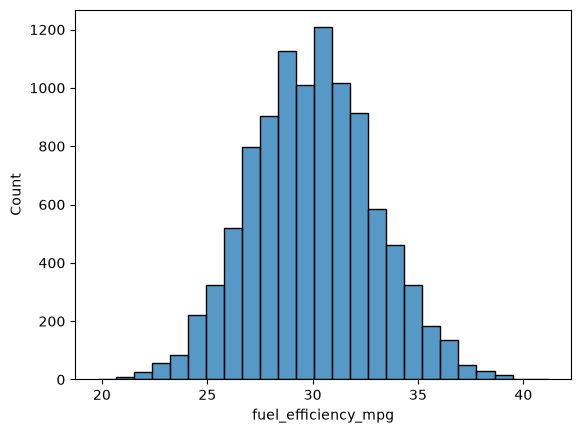

In [4]:
sns.histplot(df['fuel_efficiency_mpg'], bins=25)

# Q1

In [5]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

# Q2

In [6]:
df['horsepower'].median()

np.float64(254.0)

# Q3

In [7]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [21]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [22]:
base=['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']
X_train = df_train[base].values
y_train = df_train['fuel_efficiency_mpg']

X_val = df_val[base].values
y_val = df_val['fuel_efficiency_mpg']

X_test = df_test[base].values
y_test = df_test['fuel_efficiency_mpg']

In [23]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [73]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [25]:
def prepare_X_mean(df):
    df_num = df[base]
    df_num = df_num.fillna(df_train['horsepower'].mean())
    X = df_num.values
    return X

In [26]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [27]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).round(3)

np.float64(2.205)

In [28]:
X_train = prepare_X_mean(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_mean(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred).round(3)

np.float64(2.202)

# Q4

In [31]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [38]:
for r in  [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred).round(4)

    print(r, w0, score)

0 -153.8849618823138 2.2053
0.01 -148.3092124404723 2.2058
0.1 -111.83871039306318 2.2241
1 -32.331865964971264 2.3492
5 -7.7728522099734025 2.4094
10 -3.9871164160193766 2.4195
100 -0.40821964884790385 2.4292


# Q5

In [41]:
rmse_scores = []
for r_seed in  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(r_seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    
    base=['engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year']
    X_train = df_train[base].values
    y_train = df_train['fuel_efficiency_mpg']
    
    X_val = df_val[base].values
    y_val = df_val['fuel_efficiency_mpg']
    
    X_test = df_test[base].values
    y_test = df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)
    
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    rmse_scores.append(rmse(y_val, y_pred))

In [48]:
std = np.array(rmse_scores).std()
round(std,3)

np.float64(0.029)

# Q6

In [77]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_combined = pd.concat([df_train, df_val], ignore_index=True).reset_index(drop=True)

base=['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year']
X_train = df_combined[base].values
y_train = df_combined['fuel_efficiency_mpg']

X_test = df_test[base].values
y_test = df_test['fuel_efficiency_mpg']

X_train = prepare_X(df_combined)
w0, w = train_linear_regression_reg(X_train, y_train,r=0.001)

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
rmse(y_test, y_pred)

np.float64(2.235827747191731)